# Practical Work 04 - Delaunay Triangulation

| Information | Details     |
| ----------- | ----------- |
| Course      | Computational Geometry (`INF2604`) |
| Professor   | Waldemar Celes (<celes@inf.puc-rio.br>) |
| Student     | Gabriel Ribeiro Gomes (<ggomes@inf.puc-rio.br>, <ribeiroggabriel@gmail.com>) |

## Setup and problem definition

We need to generate a report that fulfills the following requirements:

- Implement a strategy for the Delaunay Triangulation algorithm. We're going to do 2 implementations:
    1. The incremental approach ($O(n*log(n))$); and
    2. The divide-and-conquer approach based on recursive insertion order ($O(n*log(n))$).
- The order of the execution of the algorithm goes as follows:
    1. Create the outside surrounding triangle that contains all the points.
    2. Insert the points one by one, updating the triangulation at each step.
    3. Remove the triangles that contain the vertices of the surrounding triangle.

## Helper functions

In [2]:
from __future__ import annotations

import random

from collections.abc import Iterable

import matplotlib.pyplot as plt

from pydantic import BaseModel


EPS: float = 1e-12

class Point(BaseModel):
    """2D point.

    Attributes:
        x: X coordinate.
        y: Y coordinate.
    """

    x: float
    y: float

    def as_tuple(self) -> tuple[float, float]:
        """Return coordinates as a simple tuple.

        Returns:
            Pair with x and y.
        """
        return (self.x, self.y)


class Triangle(BaseModel):
    """Triangle by vertex indices (CCW expected).

    Attributes:
        i: Index of first vertex.
        j: Index of second vertex.
        k: Index of third vertex.
    """

    i: int
    j: int
    k: int

    def as_tuple(self) -> tuple[int, int, int]:
        """Return indices as simple tuple.

        Returns:
            Triple with vertex indices.
        """
        return (self.i, self.j, self.k)

    def edges(self) -> list[tuple[int, int]]:
        """Return the three undirected edges of the triangle.

        Returns:
            List of pairs with vertex indices.
        """
        a, b, c = self.i, self.j, self.k
        return [tuple(sorted((a, b))), tuple(sorted((b, c))), tuple(sorted((c, a)))]


def orient2d(a: Point, b: Point, c: Point) -> float:
    """Signed area *2 of triangle abc (orientation test).

    Positive if a->b->c is CCW, negative if CW, near zero if colinear.

    Args:
        a: First point.
        b: Second point.
        c: Third point.

    Returns:
        Signed area times two.
    """
    return (b.x - a.x) * (c.y - a.y) - (b.y - a.y) * (c.x - a.x)


def incircle(a: Point, b: Point, c: Point, p: Point) -> float:
    """InCircle predicate for triangle abc and point p.

    Assumes triangle abc is in CCW orientation. If not, the sign must be inverted.

    Args:
        a: First triangle vertex.
        b: Second triangle vertex.
        c: Third triangle vertex.
        p: Query point.

    Returns:
        Positive if p is inside circumcircle of abc; negative if outside; ~0 on circle.
    """
    ax, ay = a.x - p.x, a.y - p.y
    bx, by = b.x - p.x, b.y - p.y
    cx, cy = c.x - p.x, c.y - p.y
    a2 = ax * ax + ay * ay
    b2 = bx * bx + by * by
    c2 = cx * cx + cy * cy
    det = (
        ax * (by * c2 - b2 * cy)
        - ay * (bx * c2 - b2 * cx)
        + a2 * (bx * cy - by * cx)
    )
    # For CCW abc, det > 0 means inside.
    return det


def ensure_ccw(p: list[Point], tri: Triangle) -> Triangle:
    """Ensure triangle has CCW orientation.

    Args:
        p: Point list.
        tri: Triangle to check.

    Returns:
        Triangle with indices ordered CCW.
    """
    a, b, c = tri.i, tri.j, tri.k
    if orient2d(p[a], p[b], p[c]) < 0:
        return Triangle(i=a, j=c, k=b)
    return tri


## Delaunay Triangulation Implementations

In [3]:
class DelaunayTriangulation:
    """Incremental Delaunay triangulation.

    Usage:
        bw = DelaunayTriangulation(points)
        triangles = bw.triangulate()

    The algorithm adds a super-triangle that contains all points, then inserts
    points one-by-one, removing triangles whose circumcircles contain the point
    and retriangulating the exposed cavity.
    """

    def __init__(self, points: list[Point]):
        """Initialize with point set.

        Args:
            points: Input point set.
        """
        self.points: list[Point] = points
        self.triangles: list[Triangle] = []
        self._super_vertices: tuple[int, int, int] | None = None

    def _build_super_triangle(self) -> None:
        """Create a big super triangle that encloses all points.

        The super-triangle is appended to the point array as three new points.
        """
        xs = [p.x for p in self.points]
        ys = [p.y for p in self.points]
        min_x, max_x = min(xs), max(xs)
        min_y, max_y = min(ys), max(ys)
        dx = max_x - min_x
        dy = max_y - min_y
        delta = max(dx, dy)
        cx = 0.5 * (min_x + max_x)
        cy = 0.5 * (min_y + max_y)

        # Create a super-triangle that comfortably contains all points.
        p1 = Point(x=cx - 2 * delta, y=cy - delta)
        p2 = Point(x=cx, y=cy + 2 * delta)
        p3 = Point(x=cx + 2 * delta, y=cy - delta)

        i1 = len(self.points)
        i2 = i1 + 1
        i3 = i1 + 2
        self.points.extend([p1, p2, p3])
        self.triangles = [ensure_ccw(self.points, Triangle(i=i1, j=i2, k=i3))]
        self._super_vertices = (i1, i2, i3)

    def _remove_super_triangle(self) -> None:
        """Remove any triangle incident to super-triangle vertices."""
        assert self._super_vertices is not None
        s = set(self._super_vertices)
        self.triangles = [t for t in self.triangles if not (set(t.as_tuple()) & s)]

    def _cavity_for_point(self, idx: int) -> tuple[list[int], list[tuple[int, int]]]:
        """Find cavity triangles and its boundary for inserting a point.

        Args:
            idx: Index of point to insert.

        Returns:
            Pair with list of triangle indices to remove and list of boundary edges.
        """
        p = self.points[idx]
        to_remove: list[int] = []
        boundary_counter: dict[tuple[int, int], int] = {}

        for t_index, tri in enumerate(self.triangles):
            a, b, c = tri.i, tri.j, tri.k
            if orient2d(self.points[a], self.points[b], self.points[c]) < 0:
                a, c = c, a
            det = incircle(self.points[a], self.points[b], self.points[c], p)
            if det > EPS:
                to_remove.append(t_index)
                for e in [
                    tuple(sorted((a, b))), tuple(sorted((b, c))), tuple(sorted((c, a)))
                ]:
                    boundary_counter[e] = boundary_counter.get(e, 0) + 1

        boundary = [e for e, count in boundary_counter.items() if count == 1]
        return to_remove, boundary

    def insert_point(self, idx: int) -> None:
        """Insert a single point into the current triangulation.

        Args:
            idx: Index of point to insert.
        """
        to_remove, boundary = self._cavity_for_point(idx)
        for t_index in sorted(to_remove, reverse=True):
            self.triangles.pop(t_index)

        for u, v in boundary:
            new_tri = ensure_ccw(self.points, Triangle(i=idx, j=u, k=v))
            self.triangles.append(new_tri)

    def triangulate(self, order: Iterable[int] | None = None) -> list[Triangle]:
        """Compute Delaunay triangulation for current points.

        Args:
            order: Optional explicit insertion order of point indices (excluding
                super-triangle vertices). If None, uses a random permutation.

        Returns:
            List of triangles in CCW orientation with original point indices.
        """
        n = len(self.points)
        self._build_super_triangle()
        start_n = n
        indices = list(range(start_n))
        if order is not None:
            indices = list(order)
        else:
            random.shuffle(indices)

        for idx in indices:
            self.insert_point(idx)

        self._remove_super_triangle()
        return self.triangles


def divide_and_conquer_order(points: list[Point]) -> list[int]:
    """Produce a recursive median-by-x insertion order (D&C flavor).

    This function returns only an **order** for insertion. The triangulation is
    still performed by the same Bowyer–Watson kernel, thus preserving correctness.

    Args:
        points: Point list.

    Returns:
        List of point indices in a recursive D&C order.
    """
    idxs = list(range(len(points)))
    idxs.sort(key=lambda i: points[i].x)

    def rec(ids: list[int]) -> list[int]:
        if len(ids) <= 1:
            return ids
        mid = len(ids) // 2
        left = rec(ids[:mid])
        right = rec(ids[mid:])
        merged: list[int] = []
        li, ri = 0, 0
        while li < len(left) or ri < len(right):
            if li < len(left):
                merged.append(left[li])
                li += 1
            if ri < len(right):
                merged.append(right[ri])
                ri += 1
        return merged

    return rec(idxs)


def triangulate_incremental(points: list[Point]) -> list[Triangle]:
    """Convenience wrapper for standard incremental Delaunay.

    Args:
        points: Input point set.

    Returns:
        List of Delaunay triangles.
    """
    bw = DelaunayTriangulation(points.copy())
    return bw.triangulate()


def triangulate_divide_and_conquer(points: list[Point]) -> list[Triangle]:
    """Triangulate using recursive D&C insertion order with Delaunay core.

    Args:
        points: Input point set.

    Returns:
        List of Delaunay triangles.
    """
    order = divide_and_conquer_order(points)
    bw = DelaunayTriangulation(points.copy())
    return bw.triangulate(order=order)



## Exporting data and plotting functions

In [19]:
def export_triangles_as_txt(triangles: list[Triangle], path: str) -> None:
    """Write triangle incidence (CCW) to a text file.

    Args:
        triangles: List of triangles.
        path: Output filepath.
    """
    with open(path, "w", encoding="utf-8") as f:
        for t in triangles:
            i, j, k = t.as_tuple()
            f.write(f"{i} {j} {k}\n")


def plot_triangulation(
        points: list[Point], triangles: list[Triangle], title: str = "Triangulation"
    ) -> None:
    """Plot a triangulation using Matplotlib with explicit axes handling.

    Args:
        points: Point list.
        triangles: Triangulation as triangles in CCW.
        title: Figure title.
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    # Draw edges
    for t in triangles:
        i, j, k = t.i, t.j, t.k
        x = [points[i].x, points[j].x, points[k].x, points[i].x]
        y = [points[i].y, points[j].y, points[k].y, points[i].y]
        ax.plot(x, y)
    # Draw points
    xs = [p.x for p in points]
    ys = [p.y for p in points]
    ax.scatter(xs, ys, s=10)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.set_aspect("equal", adjustable="box")
    plt.show()


def hull_vertex_count(points: list[Point], triangles: list[Triangle]) -> int:
    """Compute number of vertices on convex hull from triangulation edges.

    This counts edges used exactly once; their cycle length equals number of
    hull vertices.

    Args:
        points: Point list.
        triangles: Triangulation.

    Returns:
        Estimated number of convex hull vertices.
    """
    edge_count: dict[tuple[int, int], int] = {}
    for t in triangles:
        for e in t.edges():
            edge_count[e] = edge_count.get(e, 0) + 1
    hull_edges = [e for e, c in edge_count.items() if c == 1]
    # Build adjacency for hull cycle and count unique vertices
    hull_vertices: set[int] = set()
    for u, v in hull_edges:
        hull_vertices.add(u)
        hull_vertices.add(v)
    return len(hull_vertices)


def validate_counts(
        n: int, triangles: list[Triangle], h: int | None = None
    ) -> dict[str, int]:
    """Validate combinatorial counts for planar triangulations.

    Args:
        n: Number of points.
        triangles: Triangulation triangles.
        h: Optional hull vertex count (if None, will be estimated from edges).

    Returns:
        Dictionary with n, h, triangle_count_expected,
            triangle_count_observed, edge_count_expected.
    """
    t_obs = len(triangles)
    if h is None:
        h = hull_vertex_count(points=n, triangles=triangles)
    t_exp = 2 * n - 2 - h
    m_exp = 3 * n - 3 - h
    return {
        "n": n,
        "h": h,
        "triangles_expected": t_exp,
        "triangles_observed": t_obs,
        "edges_expected": m_exp,
    }


def random_points(n: int, seed: int | None = 0) -> list[Point]:
    """Generate n random points in the unit square.

    Args:
        n: Number of points.
        seed: Random seed.

    Returns:
        List of points.
    """
    rng = random.Random(seed)
    return [Point(x=rng.random(), y=rng.random()) for _ in range(n)]

## Visual example for execution

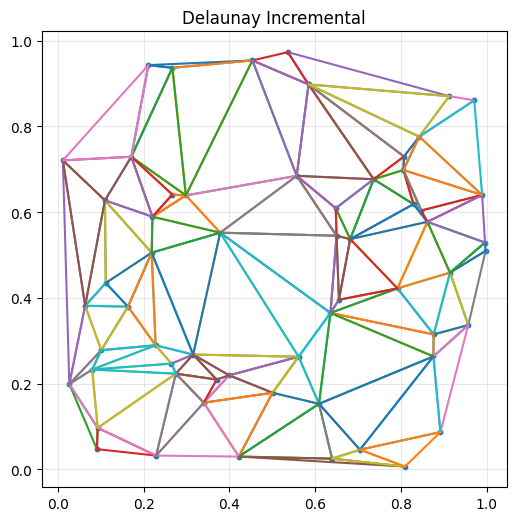

{'n': 60, 'h': 16, 'triangles_expected': 102, 'triangles_observed': 102, 'edges_expected': 161}


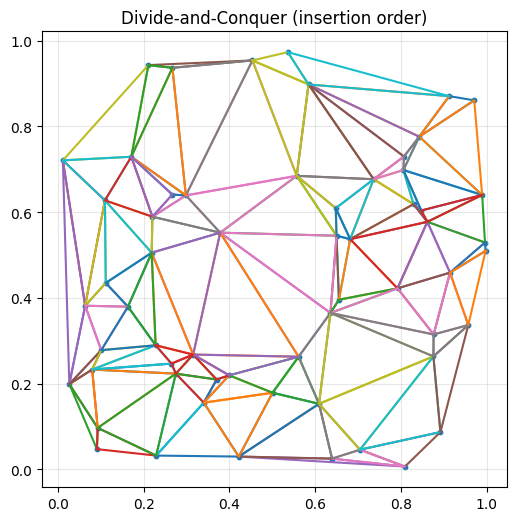

{'n': 60, 'h': 16, 'triangles_expected': 102, 'triangles_observed': 102, 'edges_expected': 161}


In [22]:
points = random_points(60, seed=42)
tris_inc = triangulate_incremental(points.copy())
tris_dc = triangulate_divide_and_conquer(points.copy())

plot_triangulation(points, tris_inc, title="Delaunay Incremental")
validation_inc = validate_counts(len(points), tris_inc)
print(validation_inc)

plot_triangulation(points, tris_dc, title="Divide-and-Conquer (insertion order)")
validation_dc = validate_counts(len(points), tris_dc)
print(validation_dc)

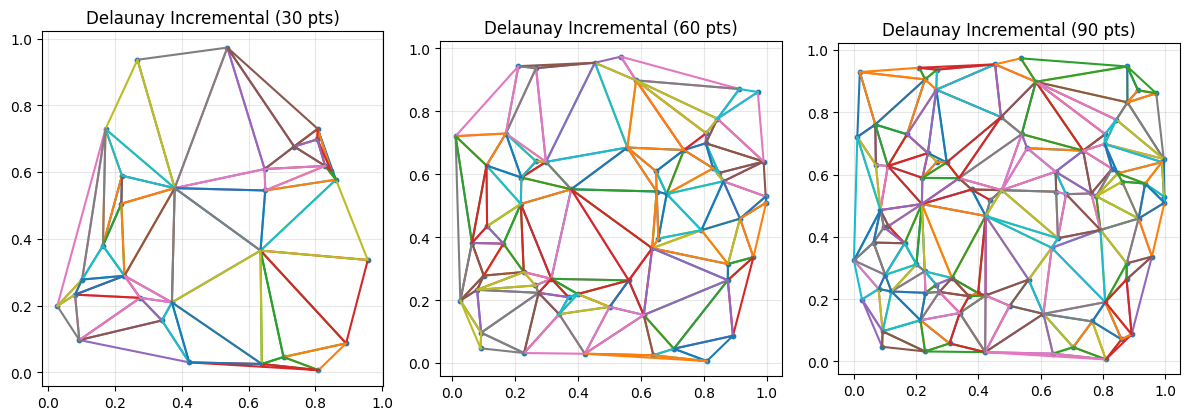

Report for 30 points:
{'n': 30, 'h': 11, 'triangles_expected': 47, 'triangles_observed': 47, 'edges_expected': 76}
Report for 60 points:
{'n': 60, 'h': 16, 'triangles_expected': 102, 'triangles_observed': 102, 'edges_expected': 161}
Report for 90 points:
{'n': 90, 'h': 17, 'triangles_expected': 161, 'triangles_observed': 161, 'edges_expected': 250}


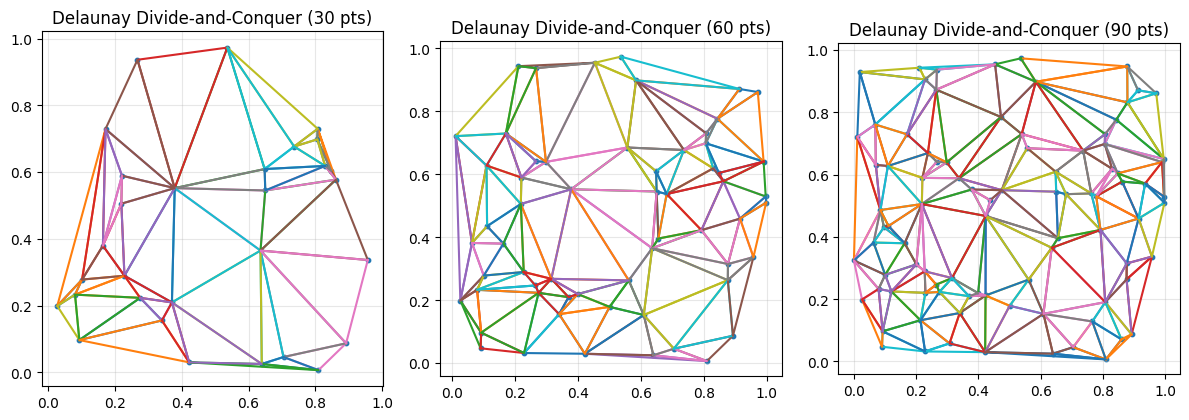

Report for 30 points:
{'n': 30, 'h': 11, 'triangles_expected': 47, 'triangles_observed': 47, 'edges_expected': 76}
Report for 60 points:
{'n': 60, 'h': 16, 'triangles_expected': 102, 'triangles_observed': 102, 'edges_expected': 161}
Report for 90 points:
{'n': 90, 'h': 17, 'triangles_expected': 161, 'triangles_observed': 161, 'edges_expected': 250}


In [28]:
points_30 = random_points(30, seed=42)
points_60 = random_points(60, seed=42)
points_90 = random_points(90, seed=42)

tris_inc_30 = triangulate_incremental(points_30.copy())
tris_dc_30 = triangulate_divide_and_conquer(points_30.copy())

tris_inc_60 = triangulate_incremental(points_60.copy())
tris_dc_60 = triangulate_divide_and_conquer(points_60.copy())

tris_inc_90 = triangulate_incremental(points_90.copy())
tris_dc_90 = triangulate_divide_and_conquer(points_90.copy())


# Incremental plots
fig, ax = plt.subplots(1, 3, figsize=(12, 6))

for t in tris_inc_30:
    i, j, k = t.i, t.j, t.k
    x = [points_30[i].x, points_30[j].x, points_30[k].x, points_30[i].x]
    y = [points_30[i].y, points_30[j].y, points_30[k].y, points_30[i].y]
    ax[0].plot(x, y)

xs_30 = [p.x for p in points_30]
ys_30 = [p.y for p in points_30]
ax[0].scatter(xs_30, ys_30, s=10)
ax[0].set_title("Delaunay Incremental (30 pts)")
ax[0].grid(alpha=0.3)
ax[0].set_aspect("equal", adjustable="box")

for t in tris_inc_60:
    i, j, k = t.i, t.j, t.k
    x = [points_60[i].x, points_60[j].x, points_60[k].x, points_60[i].x]
    y = [points_60[i].y, points_60[j].y, points_60[k].y, points_60[i].y]
    ax[1].plot(x, y)

xs_60 = [p.x for p in points_60]
ys_60 = [p.y for p in points_60]
ax[1].scatter(xs_60, ys_60, s=10)
ax[1].set_title("Delaunay Incremental (60 pts)")
ax[1].grid(alpha=0.3)
ax[1].set_aspect("equal", adjustable="box")

for t in tris_inc_90:
    i, j, k = t.i, t.j, t.k
    x = [points_90[i].x, points_90[j].x, points_90[k].x, points_90[i].x]
    y = [points_90[i].y, points_90[j].y, points_90[k].y, points_90[i].y]
    ax[2].plot(x, y)

xs_90 = [p.x for p in points_90]
ys_90 = [p.y for p in points_90]
ax[2].scatter(xs_90, ys_90, s=10)
ax[2].set_title("Delaunay Incremental (90 pts)")
ax[2].grid(alpha=0.3)
ax[2].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

print("Report for 30 points:")
validation_inc_30 = validate_counts(len(points_30), tris_inc_30)
print(validation_inc_30)
print("Report for 60 points:")
validation_inc_60 = validate_counts(len(points_60), tris_inc_60)
print(validation_inc_60)
print("Report for 90 points:")
validation_inc_90 = validate_counts(len(points_90), tris_inc_90)
print(validation_inc_90)

# Divide-and-Conquer plots
fig, ax = plt.subplots(1, 3, figsize=(12, 6))

for t in tris_dc_30:
    i, j, k = t.i, t.j, t.k
    x = [points_30[i].x, points_30[j].x, points_30[k].x, points_30[i].x]
    y = [points_30[i].y, points_30[j].y, points_30[k].y, points_30[i].y]
    ax[0].plot(x, y)

xs_30 = [p.x for p in points_30]
ys_30 = [p.y for p in points_30]
ax[0].scatter(xs_30, ys_30, s=10)
ax[0].set_title("Delaunay Divide-and-Conquer (30 pts)")
ax[0].grid(alpha=0.3)
ax[0].set_aspect("equal", adjustable="box")

for t in tris_dc_60:
    i, j, k = t.i, t.j, t.k
    x = [points_60[i].x, points_60[j].x, points_60[k].x, points_60[i].x]
    y = [points_60[i].y, points_60[j].y, points_60[k].y, points_60[i].y]
    ax[1].plot(x, y)

xs_60 = [p.x for p in points_60]
ys_60 = [p.y for p in points_60]
ax[1].scatter(xs_60, ys_60, s=10)
ax[1].set_title("Delaunay Divide-and-Conquer (60 pts)")
ax[1].grid(alpha=0.3)
ax[1].set_aspect("equal", adjustable="box")

for t in tris_dc_90:
    i, j, k = t.i, t.j, t.k
    x = [points_90[i].x, points_90[j].x, points_90[k].x, points_90[i].x]
    y = [points_90[i].y, points_90[j].y, points_90[k].y, points_90[i].y]
    ax[2].plot(x, y)

xs_90 = [p.x for p in points_90]
ys_90 = [p.y for p in points_90]
ax[2].scatter(xs_90, ys_90, s=10)
ax[2].set_title("Delaunay Divide-and-Conquer (90 pts)")
ax[2].grid(alpha=0.3)
ax[2].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

print("Report for 30 points:")
validation_dc_30 = validate_counts(len(points_30), tris_dc_30)
print(validation_dc_30)
print("Report for 60 points:")
validation_dc_60 = validate_counts(len(points_60), tris_dc_60)
print(validation_dc_60)
print("Report for 90 points:")
validation_dc_90 = validate_counts(len(points_90), tris_dc_90)
print(validation_dc_90)

## Extra: Simple benchmarking

In [12]:
from time import perf_counter


def benchmark(ns: list[int], seed: int = 0) -> dict[str, list[float]]:
    """Run timing benchmarks for both triangulators.

    Args:
        ns: List of sizes to test.
        seed: Random seed for reproducibility.

    Returns:
        Dictionary with arrays of timings.
    """
    t_inc: list[float] = []
    t_dc: list[float] = []
    for n in ns:
        pts = random_points(n, seed=seed)
        t0 = perf_counter()
        _ = triangulate_incremental(pts.copy())
        t1 = perf_counter()
        _ = triangulate_divide_and_conquer(pts.copy())
        t2 = perf_counter()
        t_inc.append(t1 - t0)
        t_dc.append(t2 - t1)
    return {"n": ns, "incremental": t_inc, "divide_and_conquer": t_dc}

ns = [*list(range(100, 1100, 100)), 2000, 5000, 10000]
res = benchmark(ns)
res

{'n': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 5000, 10000],
 'incremental': [0.01357569999890984,
  0.04072547599935206,
  0.0840870760002872,
  0.1549915650030016,
  0.2362905519985361,
  0.3323057229972619,
  0.45732172800126136,
  0.592750640000304,
  0.7396437890020024,
  0.9845511080020515,
  3.82396811000217,
  24.292922794000333,
  111.32292904899805],
 'divide_and_conquer': [0.01354838900078903,
  0.0389114019999397,
  0.08474660499996389,
  0.1576724419974198,
  0.23777939600040554,
  0.3389706660018419,
  0.4530640589982795,
  0.5942254300025525,
  0.7344071929983329,
  0.9491597009982797,
  4.109531922000315,
  22.97168740199777,
  110.05988997000168]}

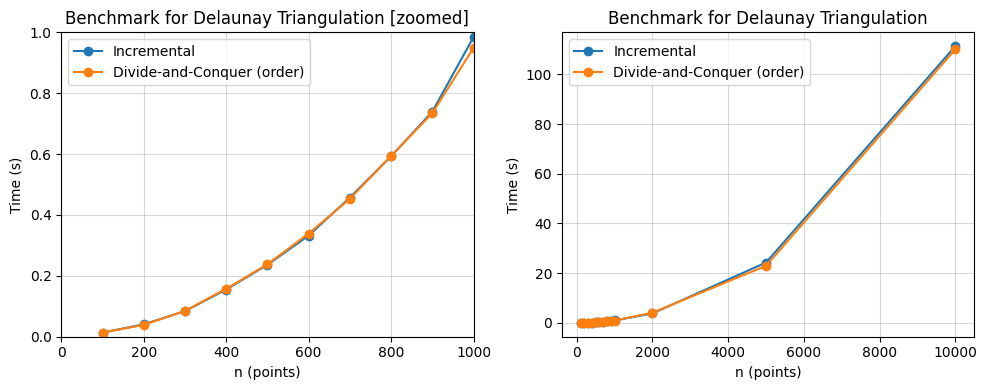

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))


ax[0].plot(res["n"], res["incremental"], marker="o", label="Incremental")
ax[0].plot(
    res["n"],
    res["divide_and_conquer"],
    marker="o",
    label="Divide-and-Conquer (order)"
)
ax[0].set_xlabel("n (points)")
ax[0].set_ylabel("Time (s)")
ax[0].set_xlim(0, 1000)
ax[0].set_ylim(0, 1)
ax[0].set_title("Benchmark for Delaunay Triangulation [zoomed]")
ax[0].legend()
ax[0].grid(alpha=0.5)

ax[1].plot(res["n"], res["incremental"], marker="o", label="Incremental")
ax[1].plot(
    res["n"],
    res["divide_and_conquer"],
    marker="o",
    label="Divide-and-Conquer (order)"
)
ax[1].set_xlabel("n (points)")
ax[1].set_ylabel("Time (s)")
ax[1].set_title("Benchmark for Delaunay Triangulation")
ax[1].legend()
ax[1].grid(alpha=0.5)


plt.tight_layout()
plt.show()